# Classification sur le réseau mondial des lignes aériennes


Tâche : **T1** = prédire le pays de chaque ville (classification de nœuds).

In [1]:
import html
import time
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from torch_geometric.data import Data
from torch_geometric.nn import LabelPropagation, Node2Vec
from torch_geometric.utils import to_undirected

warnings.filterwarnings("ignore")

RAW_PATH = Path("data/airportsAndCoordAndPop.graphml")
PROCESSED_DIR = Path("data/processed")
FIG_DIR = Path("results/figures")
RESULTS_DIR = Path("results")
for d in (PROCESSED_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

MIN_CITIES = 5          # pays avec moins de villes -> OTHER
OTHER = "OTHER"

C:\Users\Busin\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## 1. Exploration du dataset

Nœud = ville desservie par un aéroport ; arête = ligne aérienne directe (non orientée, sans poids).
Attributs : `lat`, `lon`, `population` (non utilisé), `country` (cible T1), `city_name` (non utilisé).

In [2]:
def load_graph(path=RAW_PATH):
    """Graphe NetworkX avec des nœuds renumérotés 0..N-1 (ordre des ids GraphML)."""
    G = nx.read_graphml(path)
    return nx.relabel_nodes(G, {n: i for i, n in enumerate(sorted(G.nodes, key=int))})

G = load_graph()
N = G.number_of_nodes()
attrs = [G.nodes[i] for i in range(N)]
raw = pd.DataFrame(attrs)
raw["degree"] = [G.degree(i) for i in range(N)]
raw.head()

,lon,lat,population,country,city_name,degree
0,-145.509722,-17.353889,10000,FRENCH_POLYNESIA,Anaa,2
1,-140.950000,-18.066667,10000,FRENCH_POLYNESIA,Hao Island,4
2,-149.600000,-17.550000,26357,FRENCH_POLYNESIA,Papeete,27
3,-135.000000,-23.033333,10000,FRENCH_POLYNESIA,Gambier Island,2
4,-143.657250,-16.584889,10000,FRENCH_POLYNESIA,Makemo,2


In [3]:
comps = sorted(nx.connected_components(G), key=len, reverse=True)
deg = raw["degree"]
country_counts = raw["country"].value_counts()
same_country = np.mean([attrs[u]["country"] == attrs[v]["country"] for u, v in G.edges])

stats = {
    "Nombre de nœuds": N,
    "Nombre d'arêtes": G.number_of_edges(),
    "Composantes connexes": f"{len(comps)} (géante : {len(comps[0])} nœuds)",
    "Degré moyen / médian / max": f"{deg.mean():.2f} / {deg.median():.0f} / {deg.max()}",
    "Plus gros hubs": ", ".join(f"{r.city_name} ({r.degree})"
                                 for r in raw.nlargest(5, "degree").itertuples()),
    "Nombre de pays (bruts)": raw["country"].nunique(),
    "Pays avec une seule ville": int((country_counts == 1).sum()),
    "Homophilie des arêtes (même pays)": round(same_country, 3),
}
pd.Series(stats, name="valeur").to_frame()

,valeur
Nombre de nœuds,3363
Nombre d'arêtes,13547
Composantes connexes,6 (géante : 3351 nœuds)
Degré moyen / médian / max,8.06 / 3 / 248
Plus gros hubs,"Paris (248), London (240), Frankfurt (234), Am..."
Nombre de pays (bruts),212
Pays avec une seule ville,62
Homophilie des arêtes (même pays),0.574


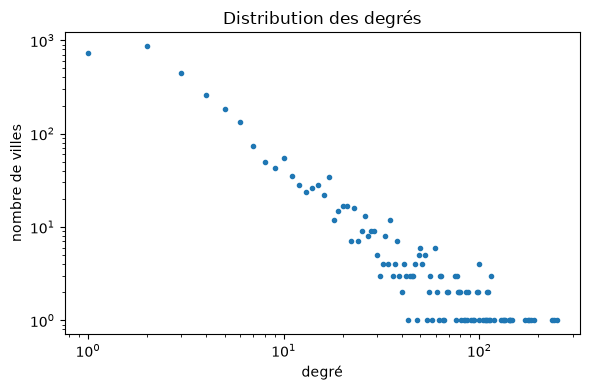

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
vc = deg.value_counts().sort_index()
ax.loglog(vc.index, vc.values, "o", ms=3)
ax.set(title="Distribution des degrés", xlabel="degré", ylabel="nombre de villes")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_degree.png", dpi=120)
plt.show()

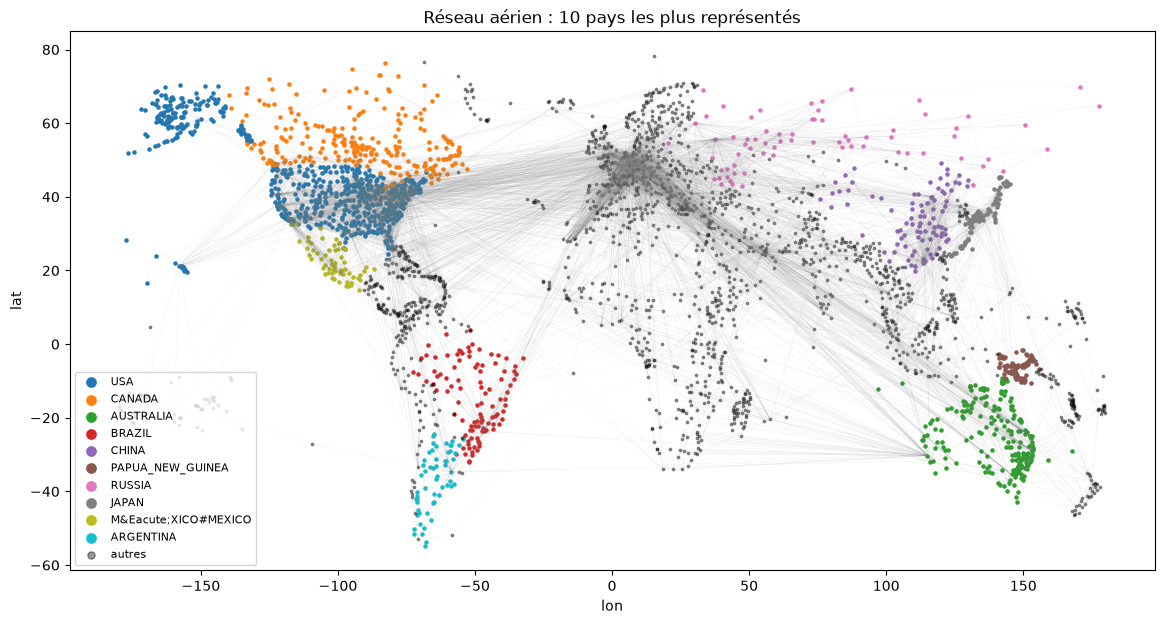

In [5]:
fig, ax = plt.subplots(figsize=(14, 7))
edges = np.array(G.edges)
lon, lat = raw["lon"].values, raw["lat"].values
# Arêtes (sans celles qui traversent l'antiméridien, pour la lisibilité)
short = np.abs(lon[edges[:, 0]] - lon[edges[:, 1]]) < 180
for u, v in edges[short]:
    ax.plot([lon[u], lon[v]], [lat[u], lat[v]], color="grey", lw=.1, alpha=.3)
top = country_counts.index[:10]
for c in top:
    m = raw["country"] == c
    ax.scatter(lon[m], lat[m], s=5, label=c)
m = ~raw["country"].isin(top)
ax.scatter(lon[m], lat[m], s=3, color="black", alpha=.4, label="autres")
ax.set(title="Réseau aérien : 10 pays les plus représentés", xlabel="lon", ylabel="lat")
ax.legend(markerscale=3, fontsize=8, loc="lower left")
plt.savefig(FIG_DIR / "01_map.png", dpi=120)
plt.show()

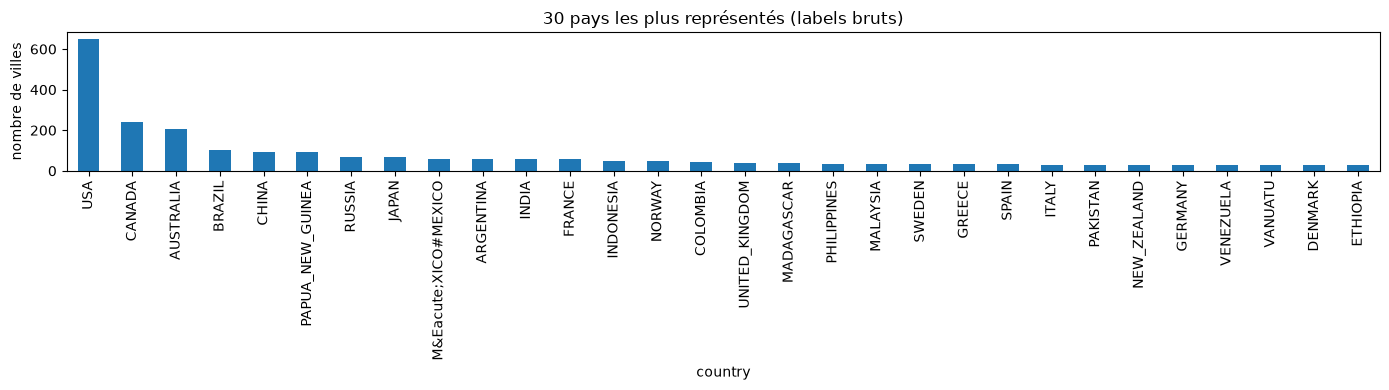

Noms bruités : ["CONGO,_DEMOCRATIC_PEOPLES'S_REPUBLIC", 'CONGO,_REPUBLIC_OF_THE', 'HA&Iuml;TI#HAITI', 'M&Eacute;XICO#MEXICO', 'PER&Uacute;#PERU', 'SAINT-PIERRE_AND_MIQUELON#ST-PIERRE_AND_MIQUELON', 'SAINT_HELENA#ST_HELENA', 'SAINT_KITTS_AND_NEVIS#ST_KITTS_AND_NEVIS', 'SAINT_LUCIA#ST_LUCIA', 'SAINT_VINCENT_AND_THE_GRENADINES#ST_VINCENT_AND_THE_GRENADINES', 'VI&Ecirc;T_NAM#VIET_NAM,VIETNAM']


In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
country_counts.head(30).plot.bar(ax=ax)
ax.set(title="30 pays les plus représentés (labels bruts)", ylabel="nombre de villes")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_countries.png", dpi=120)
plt.show()

print("Noms bruités :", sorted(c for c in country_counts.index if any(s in c for s in "&#,")))

**Piège 1 — les coordonnées contiennent presque la réponse.** Un 1-NN sur (lat, lon), sans aucune arête,
avec 50 % des nœuds en test :

In [7]:
Xc = raw[["lat", "lon"]].values
tr, te = train_test_split(np.arange(N), test_size=.5, random_state=0)
knn1 = KNeighborsClassifier(1).fit(Xc[tr], raw["country"].values[tr])
print(f"1-NN sur coordonnées : accuracy = {knn1.score(Xc[te], raw['country'].values[te]):.3f}")

1-NN sur coordonnées : accuracy = 0.839


**Deux pièges**
1. Coordonnées quasi-oracles → tout évaluer en **scénario A (avec coords)** et **B (sans coords)**.
2. Labels pays bruités et déséquilibrés → nettoyage, classe `OTHER` pour les pays < 5 villes, **F1-macro** en plus de l'accuracy.

## 2. Nettoyage et préparation des données

### 2.1 Nettoyage des labels de pays
- Si le nom contient `#`, garder la partie après le `#`.
- Si le résultat contient une virgule, garder la première forme.
- Pays avec moins de 5 villes → `OTHER`.

 La règle de la virgule n'est appliquée qu'à la partie après le `#` (liste d'alias).
Appliquée partout, elle fusionnerait `CONGO,_REPUBLIC_OF_THE` et `CONGO,_DEMOCRATIC_PEOPLES'S_REPUBLIC` en `CONGO`.

In [8]:
def clean_country(name: str) -> str:
    name = html.unescape(name).strip()
    if "#" in name:
        name = name.split("#", 1)[1].split(",", 1)[0]
    return name.strip()


def group_rare(countries, min_count=MIN_CITIES):
    counts = Counter(countries)
    return [c if counts[c] >= min_count else OTHER for c in countries]


for c in ["M&Eacute;XICO#MEXICO", "PER&Uacute;#PERU", "VI&Ecirc;T_NAM#VIET_NAM,VIETNAM",
          "CONGO,_REPUBLIC_OF_THE", "CONGO,_DEMOCRATIC_PEOPLES'S_REPUBLIC"]:
    print(f"{c:40s} -> {clean_country(c)}")

M&Eacute;XICO#MEXICO                     -> MEXICO
PER&Uacute;#PERU                         -> PERU
VI&Ecirc;T_NAM#VIET_NAM,VIETNAM          -> VIET_NAM
CONGO,_REPUBLIC_OF_THE                   -> CONGO,_REPUBLIC_OF_THE
CONGO,_DEMOCRATIC_PEOPLES'S_REPUBLIC     -> CONGO,_DEMOCRATIC_PEOPLES'S_REPUBLIC


### 2.2 Features des nœuds

La population n'est jamais utilisée comme feature.

In [9]:
def geo_features(lat, lon):
    """(cos lat·cos lon, cos lat·sin lon, sin lat) : pas de discontinuité à ±180°."""
    lat, lon = np.radians(lat), np.radians(lon)
    return np.stack([np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)], axis=1)


def structural_features(G):
    n = G.number_of_nodes()
    deg = np.array([G.degree(i) for i in range(n)], dtype=float)
    pr, cl, cc = nx.pagerank(G), nx.clustering(G), nx.closeness_centrality(G)
    feats = np.stack([
        np.log1p(deg),
        np.log([pr[i] for i in range(n)]),   # PageRank très asymétrique -> log
        [cl[i] for i in range(n)],
        [cc[i] for i in range(n)],
    ], axis=1)
    # Standardisation transductive : les features de tous les nœuds sont visibles, pas les labels
    return (feats - feats.mean(0)) / feats.std(0)

### 2.3 Conversion en `torch_geometric.data.Data`

In [10]:
def build_data(G):
    n = G.number_of_nodes()
    attrs = [G.nodes[i] for i in range(n)]
    lat = np.array([a["lat"] for a in attrs], dtype=float)
    lon = np.array([a["lon"] for a in attrs], dtype=float)

    countries = group_rare([clean_country(a["country"]) for a in attrs])
    classes = sorted(set(countries) - {OTHER}) + [OTHER]
    class_idx = {c: i for i, c in enumerate(classes)}

    x_geo = torch.tensor(geo_features(lat, lon), dtype=torch.float)
    x_struct = torch.tensor(structural_features(G), dtype=torch.float)
    edge_index = to_undirected(torch.tensor(list(G.edges)).t(), num_nodes=n)

    data = Data(
        x=torch.cat([x_geo, x_struct], dim=1),   # scénario A
        x_geo=x_geo,
        x_struct=x_struct,                        # scénario B
        edge_index=edge_index,
        y_country=torch.tensor([class_idx[c] for c in countries]),
        num_nodes=n,
    )
    # Métadonnées (jamais utilisées comme features)
    data.country_names = classes
    data.city_name = [a["city_name"] for a in attrs]
    return data


def features(data, scenario):
    return {"A": data.x, "B": data.x_struct}[scenario]


data = build_data(G)
torch.save(data, PROCESSED_DIR / "airports.pt")
NUM_CLASSES = len(data.country_names)

counts = torch.bincount(data.y_country)
print(data)
print(f"Classes pays : {NUM_CLASSES} (OTHER = {counts[-1].item()} villes, "
      f"plus grande classe = {counts.max().item()}, plus petite = {counts.min().item()})")
print(f"Homophilie des arêtes (labels nettoyés) : "
      f"{(data.y_country[data.edge_index[0]] == data.y_country[data.edge_index[1]]).float().mean():.3f}")

Data(x=[3363, 7], edge_index=[2, 27094], x_geo=[3363, 3], x_struct=[3363, 4], y_country=[3363], num_nodes=3363, country_names=[100], city_name=[3363])
Classes pays : 100 (OTHER = 203 villes, plus grande classe = 650, plus petite = 5)
Homophilie des arêtes (labels nettoyés) : 0.592


## 3. Protocole expérimental

- Scénarios : **A** (coords + structure) et **B** (structure seule).
- Taux de labels : 10 %, 30 %, 50 % pour l'entraînement ; val = 10 % ; test = le reste.
- Tous les nœuds sont candidats, découpage **stratifié par pays**.
- Cadre transductif : le graphe complet est toujours visible, seuls les labels sont cachés.
- Déséquilibre des classes : chaque modèle est lancé en mode **standard** et en mode **équilibré** (voir §4).
- 10 graines (0…9), résultats en moyenne ± écart-type, early stopping sur la validation (patience = 50).
- Hyperparamètres des GNN : Optuna sur la validation uniquement (plages ci-dessous, utilisées aux étapes suivantes).

In [11]:
SCENARIOS = ("A", "B")
LABEL_RATES = (0.1, 0.3, 0.5)
SEEDS = tuple(range(10))
VAL_RATE = 0.1
PATIENCE = 50

# Espace de recherche Optuna (pour les GNN, étapes suivantes)
SEARCH_SPACE = {
    "hidden": [32, 64, 128, 256],
    "num_layers": (1, 4),
    "dropout": (0.0, 0.6),
    "lr": (1e-4, 1e-2),          # échelle log
    "weight_decay": (0.0, 5e-4),
    "heads": [1, 2, 4, 8],       # GAT
}


def make_split(candidates, rate, seed, stratify=None):
    """train = rate, val = 10 %, test = le reste (en proportion de `candidates`)."""
    n = len(candidates)
    n_train, n_val = round(rate * n), round(VAL_RATE * n)

    def split(idx, strat, size):
        try:
            return train_test_split(idx, train_size=size, random_state=seed, stratify=strat)
        except ValueError:  # stratification impossible -> aléatoire
            return train_test_split(idx, train_size=size, random_state=seed)

    train, rest = split(candidates, stratify, n_train)
    rest_strat = None if stratify is None else stratify[np.searchsorted(candidates, rest)]
    val, test = split(rest, rest_strat, n_val)
    return {k: torch.from_numpy(np.sort(v)) for k, v in (("train", train), ("val", val), ("test", test))}


all_nodes = np.arange(data.num_nodes)
splits = {(rate, seed): make_split(all_nodes, rate, seed, stratify=data.y_country.numpy())
          for rate in LABEL_RATES for seed in SEEDS}
torch.save(splits, PROCESSED_DIR / "splits.pt")

pd.DataFrame([
    {"taux": r, **{k: len(v) for k, v in splits[(r, 0)].items()},
     "classes vues en train": len(set(data.y_country[splits[(r, 0)]["train"]].tolist()))}
    for r in LABEL_RATES
])

,taux,train,val,test,classes vues en train
0,0.1,336,336,2691,93
1,0.3,1009,336,2018,100
2,0.5,1682,336,1345,100


## 4. Baselines

Les baselines qui n'utilisent pas les features (majoritaire, Label Propagation, Node2Vec) donnent le même
score dans les deux scénarios : elles sont calculées une fois et reportées en A et en B.
Leurs quelques hyperparamètres (k, α, C…) sont choisis sur la validation par petite grille.

**Déséquilibre des classes.** Les USA ont 650 villes, 32 pays en ont moins de 10. On ne rééquilibre pas
les données : supprimer ou dupliquer des nœuds casserait la structure du graphe et rendrait le test non
représentatif. On agit sur l'apprentissage et la sélection, avec deux modes :
- **standard** : loss non pondérée, epoch et hyperparamètres choisis sur l'**accuracy** de validation ;
- **équilibré** : loss pondérée par la racine de l'inverse de la fréquence des classes (même poids pour
  le MLP et la régression logistique), sélection sur le **F1-macro** de validation. Le k-NN et la Label
  Propagation n'ont pas de loss : seul le critère de sélection change.

Métriques : accuracy, F1-macro, et F1 moyen par taille de pays (petits < 10 villes, moyens 10–49,
gros ≥ 50, et `OTHER` à part : elle regroupe des micro-pays dispersés, sans cohérence géographique).

In [12]:
MODES = ("standard", "équilibré")

# Groupes de pays par taille (sur tout le graphe) ; OTHER à part
SIZE = np.bincount(data.y_country.numpy(), minlength=NUM_CLASSES)
IS_OTHER = np.arange(NUM_CLASSES) == NUM_CLASSES - 1
GROUPS = {
    "petits (<10)": (SIZE < 10) & ~IS_OTHER,
    "moyens (10-49)": (SIZE >= 10) & (SIZE < 50) & ~IS_OTHER,
    "gros (≥50)": (SIZE >= 50) & ~IS_OTHER,
    "OTHER": IS_OTHER,
}


def evaluate(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    res = {"acc": accuracy_score(y_true, y_pred),
           "f1_macro": f1_score(y_true, y_pred, average="macro")}
    f1 = f1_score(y_true, y_pred, labels=np.arange(NUM_CLASSES), average=None, zero_division=0)
    present = np.isin(np.arange(NUM_CLASSES), y_true)   # classes présentes dans le test
    for g, m in GROUPS.items():
        res[f"f1 {g}"] = f1[m & present].mean()
    return res


def val_score(y_true, y_pred, balanced):
    """Critère de sélection sur la validation : F1-macro (mode équilibré) ou accuracy (standard)."""
    if balanced:
        return f1_score(y_true, y_pred, average="macro")
    return accuracy_score(y_true, y_pred)


def select_on_val(split, candidates, balanced):
    """candidates : dict nom -> prédictions sur tous les nœuds. Retourne les métriques test du meilleur."""
    y = data.y_country.numpy()
    va, te = split["val"].numpy(), split["test"].numpy()
    best = max(candidates, key=lambda k: val_score(y[va], candidates[k][va], balanced))
    return evaluate(y[te], candidates[best][te]), best


def class_weights(y_train, power=0.5):
    """(Inverse de la fréquence des classes dans le train) ** power, 0 pour les classes absentes.
    power = 0.5 : la pondération complète (power = 1) fait chuter l'accuracy et le F1 de OTHER
    sans gain de F1-macro à 10-30 % de labels (testé sur 5 graines)."""
    counts = torch.bincount(y_train, minlength=NUM_CLASSES).float()
    w = torch.where(counts > 0, counts.sum() / (NUM_CLASSES * counts), torch.zeros_like(counts))
    return w ** power

### 4.1 Classe majoritaire

In [13]:
def run_majority(split):
    y = data.y_country.numpy()
    tr, te = split["train"].numpy(), split["test"].numpy()
    return evaluate(y[te], np.full(len(te), np.bincount(y[tr]).argmax())), "-"

### 4.2 MLP (early stopping sur la validation, patience = 50)

In [14]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
                                 nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
                                 nn.Linear(hidden, out_dim))

    def forward(self, x):
        return self.net(x)


def run_mlp(split, scenario, seed, balanced, hidden=64, dropout=0.3, lr=1e-2, wd=5e-4, max_epochs=2000):
    torch.manual_seed(seed)
    x, y = features(data, scenario), data.y_country
    tr, va, te = split["train"], split["val"], split["test"]
    model = MLP(x.size(1), hidden, NUM_CLASSES, dropout)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    weights = class_weights(y[tr]) if balanced else None

    def predict():
        model.eval()
        with torch.no_grad():
            return model(x).argmax(1).numpy()

    best, best_pred, wait = -np.inf, None, 0
    for epoch in range(max_epochs):
        model.train()
        opt.zero_grad()
        loss = F.cross_entropy(model(x[tr]), y[tr], weight=weights)
        loss.backward()
        opt.step()

        pred = predict()
        score = val_score(y[va].numpy(), pred[va], balanced)
        if score > best:
            best, best_pred, wait = score, pred, 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break
    return evaluate(y[te].numpy(), best_pred[te]), f"epochs={epoch + 1}"

### 4.3 k-NN sur coordonnées (scénario A uniquement)

In [15]:
def run_knn(split, balanced):
    x = data.x_geo.numpy()   # distance euclidienne en (x, y, z) = monotone en la distance orthodromique
    y = data.y_country.numpy()
    tr = split["train"].numpy()
    candidates = {}
    for k in (1, 3, 5, 10, 20):
        for w in ("uniform", "distance"):
            if k <= len(tr):
                candidates[f"k={k},{w}"] = KNeighborsClassifier(k, weights=w).fit(x[tr], y[tr]).predict(x)
    return select_on_val(split, candidates, balanced)

### 4.4 Label Propagation (graphe seul)

In [16]:
def run_label_propagation(split, balanced):
    y = data.y_country
    mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    mask[split["train"]] = True
    candidates = {}
    for alpha in (0.5, 0.7, 0.9, 0.99):
        out = LabelPropagation(num_layers=50, alpha=alpha)(y, data.edge_index, mask=mask)
        pred = out.argmax(1).numpy()
        pred[split["train"].numpy()] = y[split["train"]].numpy()
        candidates[f"alpha={alpha}"] = pred
    return select_on_val(split, candidates, balanced)

### 4.5 Node2Vec + régression logistique

Les embeddings sont non supervisés (ils ne dépendent pas des labels) : un embedding par graine, mis en cache.
Marches uniformes (p = q = 1, équivalent DeepWalk) : l'échantillonneur de `pyg_lib` ne gère pas encore les marches biaisées.

In [17]:
def node2vec_embedding(seed, dim=64, epochs=10):
    path = PROCESSED_DIR / f"node2vec_seed{seed}.pt"
    if path.exists():
        return torch.load(path)
    torch.manual_seed(seed)
    model = Node2Vec(data.edge_index, embedding_dim=dim, walk_length=20, context_size=10,
                     walks_per_node=10, num_negative_samples=1, p=1.0, q=1.0,
                     num_nodes=data.num_nodes, sparse=True)
    loader = model.loader(batch_size=128, shuffle=True)
    opt = torch.optim.SparseAdam(list(model.parameters()), lr=0.01)
    model.train()
    for _ in range(epochs):
        for pos_rw, neg_rw in loader:
            opt.zero_grad()
            loss = model.loss(pos_rw, neg_rw)
            loss.backward()
            opt.step()
    emb = model.embedding.weight.detach().clone()
    torch.save(emb, path)
    return emb


def run_node2vec(split, seed, balanced):
    z = StandardScaler().fit_transform(node2vec_embedding(seed).numpy())
    y = data.y_country.numpy()
    tr = split["train"].numpy()
    cw = None
    if balanced:
        w = class_weights(torch.from_numpy(y[tr])).numpy()
        cw = {k: w[k] for k in np.unique(y[tr])}
    candidates = {}
    for c in (0.01, 0.1, 1.0, 10.0):
        m = LogisticRegression(C=c, max_iter=2000,
                               class_weight=cw).fit(z[tr], y[tr])
        candidates[f"C={c}"] = m.predict(z)
    return select_on_val(split, candidates, balanced)


t0 = time.time()
for s in SEEDS:
    node2vec_embedding(s)
print(f"Embeddings Node2Vec prêts ({time.time() - t0:.0f} s)")

Embeddings Node2Vec prêts (0 s)


### 4.6 Lancement de toutes les baselines

In [18]:
rows = []

def record(scenarios, modes, model, rate, seed, result):
    metrics, chosen = result
    for sc in scenarios:
        for mode in modes:
            rows.append({"scenario": sc, "mode": mode, "model": model, "rate": rate,
                         "seed": seed, "selected": chosen, **metrics})

t0 = time.time()
for rate in LABEL_RATES:
    for seed in SEEDS:
        split = splits[(rate, seed)]
        record(SCENARIOS, MODES, "Majoritaire", rate, seed, run_majority(split))
        for mode in MODES:
            b = mode == "équilibré"
            for sc in SCENARIOS:
                record([sc], [mode], "MLP", rate, seed, run_mlp(split, sc, seed, b))
            record(["A"], [mode], "k-NN (coords)", rate, seed, run_knn(split, b))
            record(SCENARIOS, [mode], "Label Propagation", rate, seed, run_label_propagation(split, b))
            record(SCENARIOS, [mode], "Node2Vec + LogReg", rate, seed, run_node2vec(split, seed, b))
    print(f"taux {rate:.0%} terminé ({time.time() - t0:.0f} s)")

raw_results = pd.DataFrame(rows)
raw_results.to_csv(RESULTS_DIR / "baselines_raw.csv", index=False)
raw_results.head()

taux 10% terminé (93 s)


taux 30% terminé (241 s)


taux 50% terminé (456 s)


,scenario,mode,model,rate,seed,selected,acc,f1_macro,f1 petits (<10),f1 moyens (10-49),f1 gros (≥50),f1 OTHER
0,A,standard,Majoritaire,0.1,0,-,0.193237,0.003239,0.0000,0.000000,0.026991,0.000000
1,A,équilibré,Majoritaire,0.1,0,-,0.193237,0.003239,0.0000,0.000000,0.026991,0.000000
2,B,standard,Majoritaire,0.1,0,-,0.193237,0.003239,0.0000,0.000000,0.026991,0.000000
3,B,équilibré,Majoritaire,0.1,0,-,0.193237,0.003239,0.0000,0.000000,0.026991,0.000000
4,A,standard,MLP,0.1,0,epochs=167,0.541434,0.250076,0.0958,0.256453,0.630384,0.272464


### 4.7 Résultats (moyenne ± écart-type sur 10 graines, ensemble de test)

In [19]:
MODEL_ORDER = ["Majoritaire", "MLP", "k-NN (coords)", "Label Propagation", "Node2Vec + LogReg"]
GROUP_COLS = [f"f1 {g}" for g in GROUPS]


def summary_table(metric):
    g = raw_results.groupby(["scenario", "model", "mode", "rate"])[metric].agg(["mean", "std"])
    fmt = (g["mean"].map("{:.3f}".format) + " ± " + g["std"].map("{:.3f}".format)).unstack("rate")
    fmt.columns = [f"{int(r * 100)} %" for r in fmt.columns]
    idx = pd.MultiIndex.from_product([SCENARIOS, MODEL_ORDER, MODES])
    return fmt.reindex(idx).dropna(how="all")


summary = []
for metric in ("acc", "f1_macro"):
    t = summary_table(metric)
    summary.append(t.assign(metric=metric))
    print(f"\n=== {metric} ===")
    display(t)
pd.concat(summary).to_csv(RESULTS_DIR / "baselines_summary.csv")


=== acc ===


10 %           30 %           50 %
A Majoritaire       standard   0.193 ± 0.000  0.193 ± 0.000  0.193 ± 0.000
                    équilibré  0.193 ± 0.000  0.193 ± 0.000  0.193 ± 0.000
  MLP               standard   0.562 ± 0.020  0.738 ± 0.010  0.766 ± 0.011
                    équilibré  0.529 ± 0.026  0.695 ± 0.026  0.751 ± 0.023
  k-NN (coords)     standard   0.780 ± 0.007  0.848 ± 0.006  0.865 ± 0.008
                    équilibré  0.784 ± 0.009  0.846 ± 0.007  0.866 ± 0.008
  Label Propagation standard   0.821 ± 0.014  0.868 ± 0.005  0.885 ± 0.006
                    équilibré  0.821 ± 0.015  0.868 ± 0.005  0.885 ± 0.006
  Node2Vec + LogReg standard   0.357 ± 0.010  0.455 ± 0.008  0.489 ± 0.014
                    équilibré  0.374 ± 0.023  0.474 ± 0.031  0.511 ± 0.041
B Majoritaire       standard   0.193 ± 0.000  0.193 ± 0.000  0.193 ± 0.000
                    équilibré  0.193 ± 0.000  0.193 ± 0.000  0.193 ± 0.000
  MLP               standard   0.203 ± 0.014  0.224 ± 0.031  0.260 ± 0.026
                    équilibré  0.095 ± 0.017  0.158 ± 0.012  0.198 ± 0.017
  Label Propagation standard   0.821 ± 0.014  0.868 ± 0.005  0.885 ± 0.006
                    équilibré  0.821 ± 0.015  0.868 ± 0.005  0.885 ± 0.006
  Node2Vec + LogReg standard   0.357 ± 0.010  0.455 ± 0.008  0.489 ± 0.014
                    équilibré  0.374 ± 0.023  0.474 ± 0.031  0.511 ± 0.041


=== f1_macro ===


10 %           30 %           50 %
A Majoritaire       standard   0.003 ± 0.000  0.003 ± 0.000  0.003 ± 0.000
                    équilibré  0.003 ± 0.000  0.003 ± 0.000  0.003 ± 0.000
  MLP               standard   0.273 ± 0.024  0.471 ± 0.019  0.495 ± 0.020
                    équilibré  0.283 ± 0.021  0.491 ± 0.036  0.580 ± 0.027
  k-NN (coords)     standard   0.616 ± 0.020  0.730 ± 0.015  0.762 ± 0.023
                    équilibré  0.630 ± 0.010  0.729 ± 0.020  0.771 ± 0.019
  Label Propagation standard   0.689 ± 0.028  0.779 ± 0.016  0.802 ± 0.013
                    équilibré  0.689 ± 0.028  0.779 ± 0.016  0.804 ± 0.010
  Node2Vec + LogReg standard   0.071 ± 0.011  0.147 ± 0.006  0.193 ± 0.013
                    équilibré  0.102 ± 0.007  0.207 ± 0.013  0.266 ± 0.025
B Majoritaire       standard   0.003 ± 0.000  0.003 ± 0.000  0.003 ± 0.000
                    équilibré  0.003 ± 0.000  0.003 ± 0.000  0.003 ± 0.000
  MLP               standard   0.020 ± 0.011  0.021 ± 0.016  0.042 ± 0.019
                    équilibré  0.053 ± 0.015  0.088 ± 0.012  0.101 ± 0.023
  Label Propagation standard   0.689 ± 0.028  0.779 ± 0.016  0.802 ± 0.013
                    équilibré  0.689 ± 0.028  0.779 ± 0.016  0.804 ± 0.010
  Node2Vec + LogReg standard   0.071 ± 0.011  0.147 ± 0.006  0.193 ± 0.013
                    équilibré  0.102 ± 0.007  0.207 ± 0.013  0.266 ± 0.025

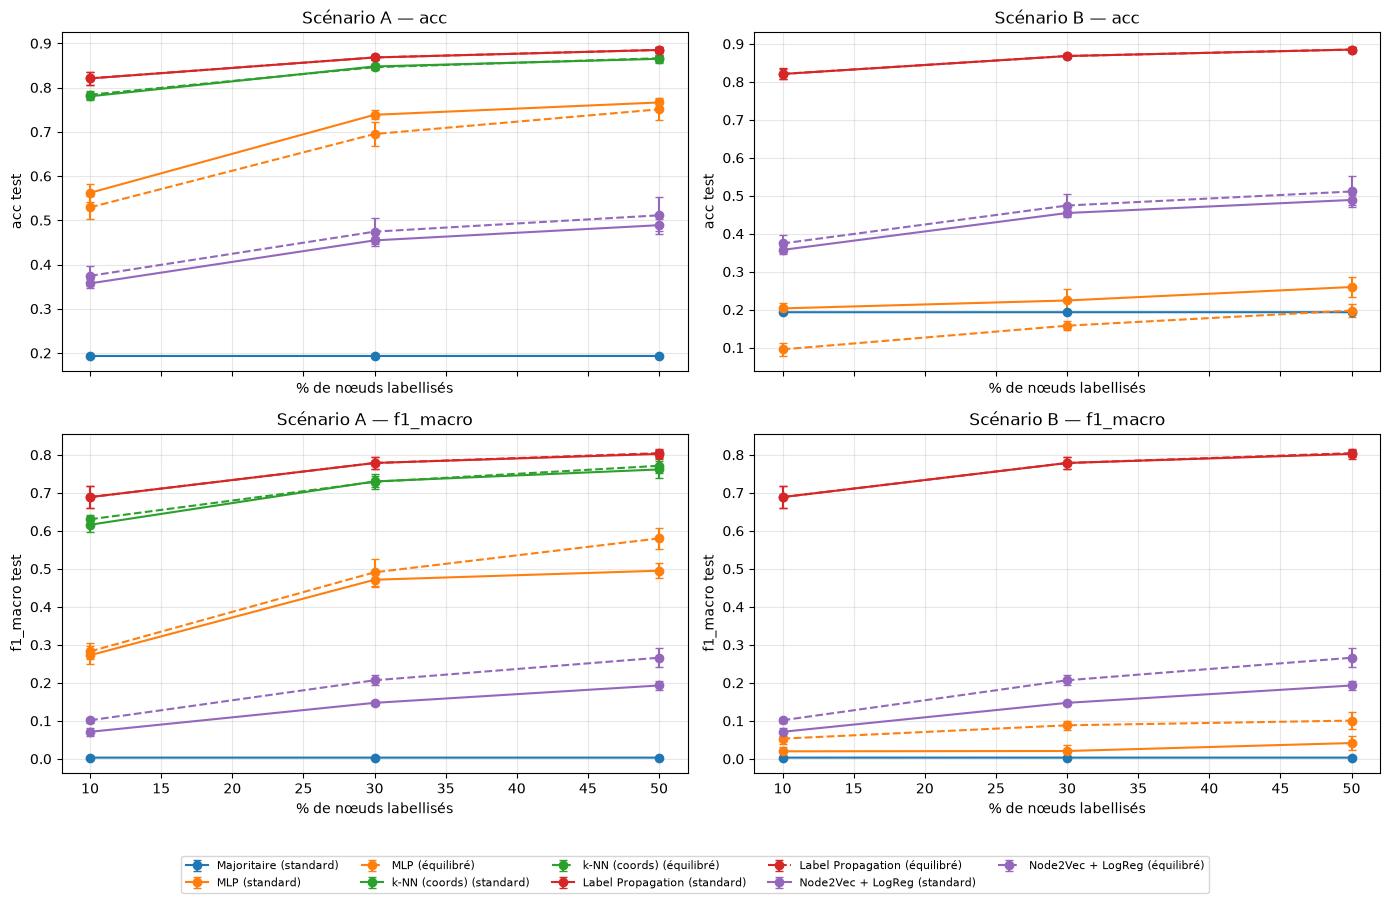

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for col, sc in enumerate(SCENARIOS):
    d_sc = raw_results[raw_results.scenario == sc]
    for row, metric in enumerate(("acc", "f1_macro")):
        ax = axes[row, col]
        for i, model in enumerate(MODEL_ORDER):
            for mode, ls in zip(MODES, ("-", "--")):
                d = d_sc[(d_sc.model == model) & (d_sc["mode"] == mode)]
                if d.empty or (model == "Majoritaire" and mode == "équilibré"):
                    continue
                g = d.groupby("rate")[metric].agg(["mean", "std"])
                ax.errorbar(g.index * 100, g["mean"], yerr=g["std"], color=f"C{i}", ls=ls,
                            marker="o", capsize=3, label=f"{model} ({mode})")
        ax.set(title=f"Scénario {sc} — {metric}", xlabel="% de nœuds labellisés", ylabel=f"{metric} test")
        ax.grid(alpha=.3)
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="lower center", ncol=5, fontsize=8)
plt.tight_layout(rect=(0, 0.07, 1, 1))
plt.savefig(FIG_DIR / "04_baselines_t1.png", dpi=120)
plt.show()

### 4.8 F1 par taille de pays

Moyenne du F1 par classe dans chaque groupe (classes présentes dans le test), moyenne sur 10 graines.

In [21]:
sizes = pd.Series({g: f"{int(m.sum())} classes" for g, m in GROUPS.items()}, name="taille")
display(sizes.to_frame().T)

by_group = (raw_results.groupby(["rate", "scenario", "model", "mode"])[GROUP_COLS].mean()
            .rename(columns=lambda c: c[3:]).round(3))
by_group.to_csv(RESULTS_DIR / "baselines_f1_by_group.csv")
for rate in LABEL_RATES:
    print(f"\n=== {int(rate * 100)} % de labels ===")
    t = by_group.loc[rate].reindex(pd.MultiIndex.from_product([SCENARIOS, MODEL_ORDER, MODES])).dropna(how="all")
    display(t)

,petits (<10),moyens (10-49),gros (≥50),OTHER
taille,32 classes,55 classes,12 classes,1 classes



=== 10 % de labels ===


petits (<10)  moyens (10-49)  gros (≥50)  OTHER
A Majoritaire       standard          0.000           0.000       0.027  0.000
                    équilibré         0.000           0.000       0.027  0.000
  MLP               standard          0.088           0.297       0.651  0.267
                    équilibré         0.098           0.315       0.636  0.180
  k-NN (coords)     standard          0.413           0.690       0.837  0.367
                    équilibré         0.430           0.707       0.836  0.367
  Label Propagation standard          0.466           0.780       0.886  0.427
                    équilibré         0.466           0.780       0.887  0.427
  Node2Vec + LogReg standard          0.000           0.040       0.394  0.185
                    équilibré         0.004           0.084       0.434  0.179
B Majoritaire       standard          0.000           0.000       0.027  0.000
                    équilibré         0.000           0.000       0.027  0.000
  MLP               standard          0.001           0.008       0.115  0.116
                    équilibré         0.021           0.055       0.130  0.070
  Label Propagation standard          0.466           0.780       0.886  0.427
                    équilibré         0.466           0.780       0.887  0.427
  Node2Vec + LogReg standard          0.000           0.040       0.394  0.185
                    équilibré         0.004           0.084       0.434  0.179


=== 30 % de labels ===


petits (<10)  moyens (10-49)  gros (≥50)  OTHER
A Majoritaire       standard          0.000           0.000       0.027  0.000
                    équilibré         0.000           0.000       0.027  0.000
  MLP               standard          0.183           0.563       0.831  0.359
                    équilibré         0.257           0.569       0.790  0.088
  k-NN (coords)     standard          0.565           0.794       0.897  0.485
                    équilibré         0.561           0.795       0.894  0.491
  Label Propagation standard          0.590           0.861       0.921  0.565
                    équilibré         0.590           0.861       0.921  0.565
  Node2Vec + LogReg standard          0.002           0.148       0.528  0.207
                    équilibré         0.015           0.241       0.562  0.190
B Majoritaire       standard          0.000           0.000       0.027  0.000
                    équilibré         0.000           0.000       0.027  0.000
  MLP               standard          0.001           0.009       0.118  0.121
                    équilibré         0.038           0.094       0.200  0.080
  Label Propagation standard          0.590           0.861       0.921  0.565
                    équilibré         0.590           0.861       0.921  0.565
  Node2Vec + LogReg standard          0.002           0.148       0.528  0.207
                    équilibré         0.015           0.241       0.562  0.190


=== 50 % de labels ===


petits (<10)  moyens (10-49)  gros (≥50)  OTHER
A Majoritaire       standard          0.000           0.000       0.027  0.000
                    équilibré         0.000           0.000       0.027  0.000
  MLP               standard          0.176           0.604       0.850  0.417
                    équilibré         0.358           0.662       0.836  0.101
  k-NN (coords)     standard          0.615           0.819       0.905  0.555
                    équilibré         0.632           0.826       0.905  0.560
  Label Propagation standard          0.624           0.880       0.933  0.634
                    équilibré         0.630           0.881       0.933  0.637
  Node2Vec + LogReg standard          0.006           0.220       0.567  0.205
                    équilibré         0.062           0.312       0.607  0.170
B Majoritaire       standard          0.000           0.000       0.027  0.000
                    équilibré         0.000           0.000       0.027  0.000
  MLP               standard          0.001           0.028       0.200  0.195
                    équilibré         0.034           0.112       0.229  0.091
  Label Propagation standard          0.624           0.880       0.933  0.634
                    équilibré         0.630           0.881       0.933  0.637
  Node2Vec + LogReg standard          0.006           0.220       0.567  0.205
                    équilibré         0.062           0.312       0.607  0.170

**À vérifier dans les tableaux :**
- Scénario A : le k-NN sur coordonnées est la baseline forte ; un GNN devra la battre pour être utile.
- Scénario B : le MLP (features structurelles seules) devrait s'effondrer, tandis que Label Propagation et Node2Vec devraient bien résister.

## 5. Discussion des résultats

*Chiffres : moyenne sur 10 graines, ensemble de test (voir tableaux des §4.7 et §4.8).*

### Mode standard

| Accuracy (F1-macro) | 10 % | 30 % | 50 % |
|---|---|---|---|
| Majoritaire | 0.193 (0.003) | 0.193 (0.003) | 0.193 (0.003) |
| MLP — A | 0.562 (0.273) | 0.738 (0.471) | 0.766 (0.495) |
| MLP — B | 0.203 (0.020) | 0.224 (0.021) | 0.260 (0.042) |
| k-NN coords — A | 0.780 (0.616) | 0.848 (0.730) | 0.865 (0.762) |
| **Label Propagation** | **0.821 (0.689)** | **0.868 (0.779)** | **0.885 (0.802)** |
| Node2Vec + LogReg | 0.357 (0.071) | 0.455 (0.147) | 0.489 (0.193) |

**1. Le graphe à lui seul suffit presque.** La Label Propagation, qui n'utilise *aucune* feature, est la meilleure baseline à tous les taux de labels, devant le k-NN sur coordonnées. C'est cohérent avec la forte homophilie des arêtes (0.59 après nettoyage) : la majorité des lignes aériennes relient deux villes du même pays (vols intérieurs). L'écart avec le k-NN est le plus grand quand les labels sont rares (+4 points à 10 %) : la propagation exploite la structure des nœuds non labellisés, ce que le k-NN ne peut pas faire.

**2. Le piège 1 est confirmé.** Le k-NN sur coordonnées atteint 0.865 à 50 % de labels, en accord avec l'estimation de ≈ 85 %. Dans le scénario A, un GNN qui utilise les coordonnées doit donc battre **0.885 (Label Propagation)**, et pas seulement 0.865, pour justifier sa complexité.

**3. Le scénario B isole bien l'apport du graphe.** Sans coordonnées, le MLP s'effondre (0.26, à peine au-dessus de la classe majoritaire à 0.19) : degré, PageRank, clustering et centralité décrivent le *rôle* d'une ville dans le réseau (hub, ville isolée…), pas *où* elle se trouve. Un GNN en scénario B ne peut donc réussir que par le passage de messages, ce qui en fait le cadre le plus informatif pour la suite.

**4. Le MLP en A reste loin du k-NN** (0.766 contre 0.865), alors qu'il dispose des mêmes coordonnées. Un MLP à 2 couches apprend mal les frontières très irrégulières entre 100 pays dans l'espace (x, y, z) ; le k-NN, non paramétrique, les capture directement.

**5. Node2Vec déçoit, contrairement à ce qui était attendu.** Les embeddings capturent la proximité dans le réseau, mais une régression logistique sur 100 classes déséquilibrées, avec seulement 64 dimensions, 10 epochs et des marches uniformes (p = q = 1, DeepWalk), reste loin de la Label Propagation. Pistes : plus d'epochs, dimension 128, des marches biaisées vers le voisinage local (q > 1, plus « BFS ») pour mieux refléter l'homophilie, ou un k-NN sur les embeddings plutôt qu'un classifieur linéaire.

**6. Le F1-macro révèle le déséquilibre (piège 2).** L'écart accuracy / F1-macro est important partout (0.885 contre 0.802 pour la Label Propagation, 0.489 contre 0.193 pour Node2Vec) : les petits pays sont bien moins bien classés que les USA, le Canada ou l'Australie. La classe majoritaire obtient 0.193 d'accuracy mais 0.003 de F1-macro, ce qui montre pourquoi l'accuracy seule serait trompeuse.

### Mode équilibré : effet de la correction du déséquilibre

| Accuracy (F1-macro), 50 % de labels | standard | équilibré |
|---|---|---|
| MLP — A | 0.766 (0.495) | 0.751 (**0.580**) |
| MLP — B | 0.260 (0.042) | 0.198 (0.101) |
| k-NN coords — A | 0.865 (0.762) | 0.866 (0.771) |
| Label Propagation | 0.885 (0.802) | 0.885 (0.804) |
| Node2Vec + LogReg | 0.489 (0.193) | **0.511 (0.266)** |

| F1 par taille de pays, 50 % de labels | petits (<10) | moyens (10–49) | gros (≥50) | OTHER |
|---|---|---|---|---|
| MLP — A standard | 0.176 | 0.604 | 0.850 | 0.417 |
| MLP — A équilibré | **0.358** | 0.662 | 0.836 | 0.101 |
| k-NN coords — A | 0.615 | 0.819 | 0.905 | 0.555 |
| Label Propagation | 0.624 | 0.880 | 0.933 | 0.634 |

**7. La pondération aide les modèles qui ont une loss.** Pour le MLP-A, le F1-macro passe de 0.495 à 0.580 à 50 % de labels, pour une perte d'accuracy de 1,5 point seulement. Le F1 des petits pays double (0.18 → 0.36). Node2Vec gagne sur les deux métriques (+2 points d'accuracy, +7 points de F1-macro) : sans pondération, sa régression logistique ne prédisait quasiment jamais les petits pays (F1 ≈ 0). La pondération complète (inverse de la fréquence) a été testée : elle était trop agressive (accuracy du MLP-A à 0.63, F1-macro plus bas qu'en standard à 10 et 30 %). On utilise donc sa racine carrée.

**8. Le compromis accuracy / F1-macro est réel.** Le modèle équilibré se trompe un peu plus sur les gros pays (F1 0.850 → 0.836) pour mieux réussir les petits. Aucune version n'est « la bonne » : elles répondent à deux questions différentes, d'où les deux métriques rapportées.

**9. La classe OTHER est la grande perdante de la pondération** (MLP-A : 0.417 → 0.101). Avec 203 villes, elle reçoit un poids faible, alors qu'elle regroupe des dizaines de micro-pays dispersés sur tous les continents : elle n'a aucune cohérence géographique et le MLP ne l'apprend qu'à force d'exemples. Le k-NN et la Label Propagation la traitent mieux (≈ 0.56–0.63), car ils raisonnent localement.

**10. Les méthodes sans loss bougent à peine.** Pour le k-NN et la Label Propagation, seul le critère de sélection change (F1-macro au lieu de l'accuracy) et les écarts restent dans le bruit. La Label Propagation est déjà robuste au déséquilibre : une petite ville a souvent des voisins de son propre pays, quelle que soit la taille de ce pays.

**11. Scénario B : la pondération ne fait pas de miracle.** Le MLP-B passe de 0.042 à 0.101 de F1-macro, mais perd 6 points d'accuracy : sans information de position, il ne sait pas *quel* petit pays prédire.

**Pour le rapport :** « Les classes sont fortement déséquilibrées (USA : 650 villes, 32 pays avec moins de 10 villes). Nous ne rééquilibrons pas les données, pour préserver la structure du graphe et un test représentatif. Nous agissons sur l'apprentissage (loss pondérée par la racine de l'inverse de la fréquence des classes) et sur l'évaluation (F1-macro et F1 par taille de pays en plus de l'accuracy). »

### Conclusions pour la suite (GNN)

- **Scénario A** : l'objectif est de battre 0.885 / F1 0.802 (Label Propagation), pas seulement le k-NN. Un GNN qui combine coordonnées et passage de messages devrait pouvoir cumuler les deux signaux.
- **Scénario B** : c'est là qu'un GNN a le plus à prouver. Il part des mêmes features que le MLP (0.26) et doit se rapprocher de la Label Propagation. Des architectures qui propagent bien les labels, comme APPNP ou un GCN combiné à de la Label Propagation (C&S), sont de bons candidats.
- **Déséquilibre** : les GNN doivent être lancés dans les deux modes, avec les mêmes poids (`class_weights`) et le même critère de sélection que les baselines, sinon un GNN pondéré aurait un avantage qui ne viendrait pas du graphe. Le F1 de `OTHER` est à surveiller séparément.
- **Limites des baselines** : les hyperparamètres sont choisis sur une petite grille et le MLP n'est pas passé par Optuna. Il faudra appliquer la même recherche Optuna aux baselines et aux GNN pour que la comparaison soit équitable. Le F1-macro de validation est bruité (336 villes, beaucoup de petits pays y ont 0 ou 1 ville) : d'où l'importance des 10 graines.